#Effect of Label Noise on Decision Tree Performance

## Introduction

Previous experiments investigated the effect of label noise on Logistic Regression performance using the Titanic dataset.

In this experiment, the same label noise procedure will be applied to a Decision Tree classifier.

Different levels of label noise will be introduced into the target variable, while the features and experimental conditions remain unchanged.

The objective is to determine how sensitive the Decision Tree model is to incorrect target labels.

## Import Libraries

The following libraries are required for data processing, model training, evaluation, and visualization.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)

import matplotlib.pyplot as plt

## Load Dataset

The Titanic dataset is loaded into a pandas DataFrame.

The same dataset and preprocessing approach used in the previous experiments are used to ensure that the results can be compared consistently.

In [14]:
df = pd.read_csv("Titanic-Dataset.csv")

## Data Preparation

Before introducing label noise, the dataset must be preprocessed.

Missing values are handled, categorical variables are converted into numerical values using one-hot encoding, and unnecessary columns are removed.

This ensures that the experiment focuses on the effect of incorrect target labels rather than preprocessing differences.

In [15]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = pd.get_dummies(df,columns=["Sex", "Embarked"],drop_first=True)

df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

## Create a Clean Dataset

A copy of the preprocessed dataset is created.

The clean dataset is kept unchanged so that different noisy versions can be generated from the same original data.

In [16]:
clean_df = df.copy()

## Label Noise Injection

A function is created to introduce label noise into the target variable.

A specified fraction of the Survived labels is randomly selected and flipped. For example, a value of 1 becomes 0, while a value of 0 becomes 1.

This simulates incorrectly recorded target labels in a real-world dataset.

In [21]:
def add_noise(dataframe, noise_fraction, random_state=42):

    noisy_df = dataframe.copy()

    noisy_indices = noisy_df.sample(frac=noise_fraction,random_state=random_state).index

    noisy_df.loc[noisy_indices, "Survived" ] = 1 - noisy_df.loc[ noisy_indices,"Survived"]

    return noisy_df

## Create Noisy Versions of the Dataset

Four versions of the dataset are created containing 0%, 10%, 20%, and 30% label noise.

The 0% noise dataset is used as the baseline, while the other datasets contain increasingly unreliable target labels.

In [31]:
noisy_10 = add_noise(clean_df, 0.10)
noisy_20 = add_noise(clean_df, 0.20)
noisy_30 = add_noise(clean_df, 0.30)

datasets = {"0% noise": clean_df,"10% noise": noisy_10,"20% noise": noisy_20,"30% noise": noisy_30}

## Train and Evaluate Decision Tree

A separate Decision Tree classifier is trained on each version of the dataset.

The same train-test split and random state are used for every experiment so that the results can be compared fairly.

Accuracy, Precision, Recall, F1-score, and the confusion matrix are calculated for each noise level.

In [9]:
results = {}

for name, data in datasets.items():

    X = data.drop(columns=["Survived"])
    y = data["Survived"]

    X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42)

    model = DecisionTreeClassifier(random_state=42)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix( y_test,y_pred).ravel()

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp}

## Results

The results from each noise level are combined into a single table.

This table allows the effect of increasing label noise on Decision Tree performance to be evaluated using several classification metrics

In [10]:
comparison = pd.DataFrame(results).T

comparison = comparison.round(3)

comparison

,Accuracy,Precision,Recall,F1-score,True Negative,False Positive,False Negative,True Positive
0% noise,0.782,0.727,0.757,0.742,84.0,21.0,18.0,56.0
10% noise,0.531,0.545,0.462,0.500,53.0,35.0,49.0,42.0
20% noise,0.223,0.286,0.208,0.240,18.0,55.0,84.0,22.0
30% noise,0.352,0.434,0.343,0.383,27.0,47.0,69.0,36.0


## Accuracy Comparison

The following graph shows how Decision Tree Accuracy changes as the level of label noise increases.

This visualization helps identify how incorrect target labels affect the model's overall classification performance.

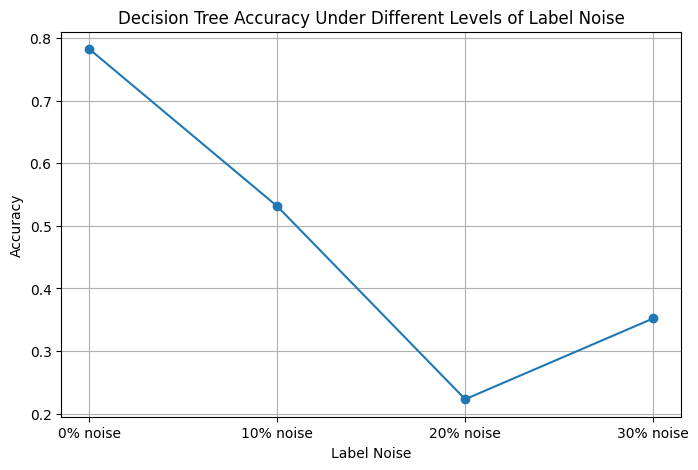

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(comparison.index,comparison["Accuracy"],marker="o")

plt.xlabel("Label Noise")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy Under Different Levels of Label Noise")

plt.grid(True)

plt.savefig("decision_tree_accuracy_label_noise.png")

plt.show()

## F1-score Comparison

The following graph shows the change in F1-score as the level of label noise increases.

The F1-score combines Precision and Recall into a single metric, making it useful for evaluating the overall balance of the model's classification performance.

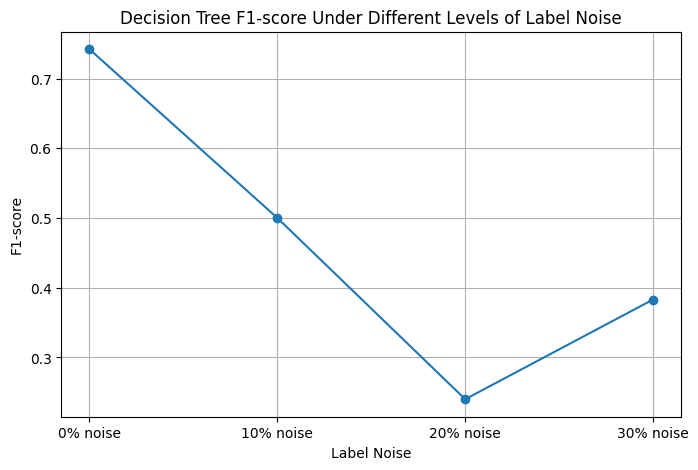

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(comparison.index,comparison["F1-score"],marker="o")

plt.xlabel("Label Noise")
plt.ylabel("F1-score")
plt.title("Decision Tree F1-score Under Different Levels of Label Noise")

plt.grid(True)

plt.savefig("decision_tree_f1_label_noise.png")

plt.show()

## Analysis of Results

The results show that increasing label noise has a strong negative effect on the performance of the Decision Tree model.

With 0% label noise, the model achieved an Accuracy of 0.782 and an F1-score of 0.742, representing its best overall performance.

When 10% label noise was introduced, Accuracy decreased to 0.531 and the F1-score decreased to 0.500. At 20% noise, the performance dropped further, reaching an Accuracy of 0.223 and an F1-score of 0.240.

At 30% noise, the model showed a partial recovery, with Accuracy increasing to 0.352 and the F1-score increasing to 0.383. However, both values remained significantly lower than the results obtained with clean data.

The confusion matrix also shows a substantial increase in classification errors as label noise increases. In particular, False Negatives increased from 18 at 0% noise to 84 at 20% noise, while True Positives decreased from 56 to 22.

Overall, the results indicate that the Decision Tree model is highly sensitive to incorrect target labels. Label noise makes it more difficult for the model to learn the relationship between the input features and the correct target values.

## Conclusion

In this experiment, the influence of label noise on Decision Tree performance was investigated using the Titanic dataset.

The results demonstrate that incorrect target labels can significantly reduce classification performance. Accuracy decreased from 0.782 with clean data to 0.223 at 20% label noise, while the F1-score decreased from 0.742 to 0.240.

Although the model showed some recovery at 30% noise, its performance remained considerably lower than with the original dataset.

These findings demonstrate that label quality is an important factor in machine learning. Incorrect target labels can prevent a model from learning reliable patterns and can lead to a substantial increase in prediction errors.